In [8]:
import os
import json

# 1. Correct the paths (nikon_test was pointing to 'train/' in your snippet)
nikon_train = 'data/Nikon750_subset/train/'
nikon_val = 'data/Nikon750_subset/val/'
nikon_test = 'data/Nikon750_subset/test/' 

# 2. Put the directories in a list so we can iterate over them
img_dirs = [nikon_train, nikon_val, nikon_test]

# 3. Load the JSON (this part was fine)
train_info = r'data\Nikon750_subset\train.json'
val_info = r'data\Nikon750_subset\val.json'
test_info = r'data\Nikon750_subset\test.json'

with open(train_info, "r") as f:
    data = json.load(f)

print("JSON Keys:", data.keys())

# 4. Count files in each directory and sum them up
total_images = 0
for folder in img_dirs:
    try:
        # Get list of files in this specific folder
        files = os.listdir(folder)
        count = len(files)
        print(f"Found {count} images in {folder}")
        total_images += count
    except FileNotFoundError:
        print(f"Warning: Could not find folder: {folder}")

print(f"Total images across all dirs: {total_images}")

JSON Keys: dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])
Found 320 images in data/Nikon750_subset/train/
Found 40 images in data/Nikon750_subset/val/
Found 40 images in data/Nikon750_subset/test/
Total images across all dirs: 400


In [9]:
def count_split(json_path):
    with open(json_path, "r") as f:
        data = json.load(f)
    return len(data["images"])


train_count = count_split(train_info)
val_count   = count_split(val_info)
test_count  = count_split(test_info)

print("Train:", train_count)
print("Val  :", val_count)
print("Test :", test_count)

total_split = train_count + val_count + test_count

print("\nSanity check:")
print("Sum of splits:", total_split)
# print("Missing images:", len(os.listdir(nikon_data_root)) - total_split)

Train: 320
Val  : 40
Test : 40

Sanity check:
Sum of splits: 400


In [10]:
# total_images_disk = len([
#     f for f in os.listdir(nikon_data_root)
#     if f.lower().endswith((".jpg", ".png", ".jpeg"))
# ])

print("Total images on disk:", total_images)

def pct(part, whole):
    return 100 * part / whole

print("\nPercentages (w.r.t total images):")
print(f"Train: {pct(train_count, total_images):.2f}%")
print(f"Val  : {pct(val_count, total_images):.2f}%")
print(f"Test : {pct(test_count, total_images):.2f}%")


Total images on disk: 400

Percentages (w.r.t total images):
Train: 80.00%
Val  : 10.00%
Test : 10.00%


In [11]:
import json

def load_filenames(json_path):
    with open(json_path, "r") as f:
        data = json.load(f)
    return set(img["file_name"] for img in data["images"])


train_files = load_filenames(train_info)
val_files   = load_filenames(val_info)
test_files  = load_filenames(test_info)

# intersections
train_val_overlap  = train_files & val_files
train_test_overlap = train_files & test_files
val_test_overlap   = val_files & test_files

print("=== Split Leakage Check ===")
print(f"Train images: {len(train_files)}")
print(f"Val images  : {len(val_files)}")
print(f"Test images : {len(test_files)}\n")

print(f"Train ∩ Val : {len(train_val_overlap)}")
print(f"Train ∩ Test: {len(train_test_overlap)}")
print(f"Val ∩ Test  : {len(val_test_overlap)}")

def print_samples(name, s, k=5):
    if len(s) > 0:
        print(f"\n{name} examples:")
        for f in list(s)[:k]:
            print(" ", f)

print_samples("Train ∩ Val", train_val_overlap)
print_samples("Train ∩ Test", train_test_overlap)
print_samples("Val ∩ Test", val_test_overlap)

=== Split Leakage Check ===
Train images: 320
Val images  : 40
Test images : 40

Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0


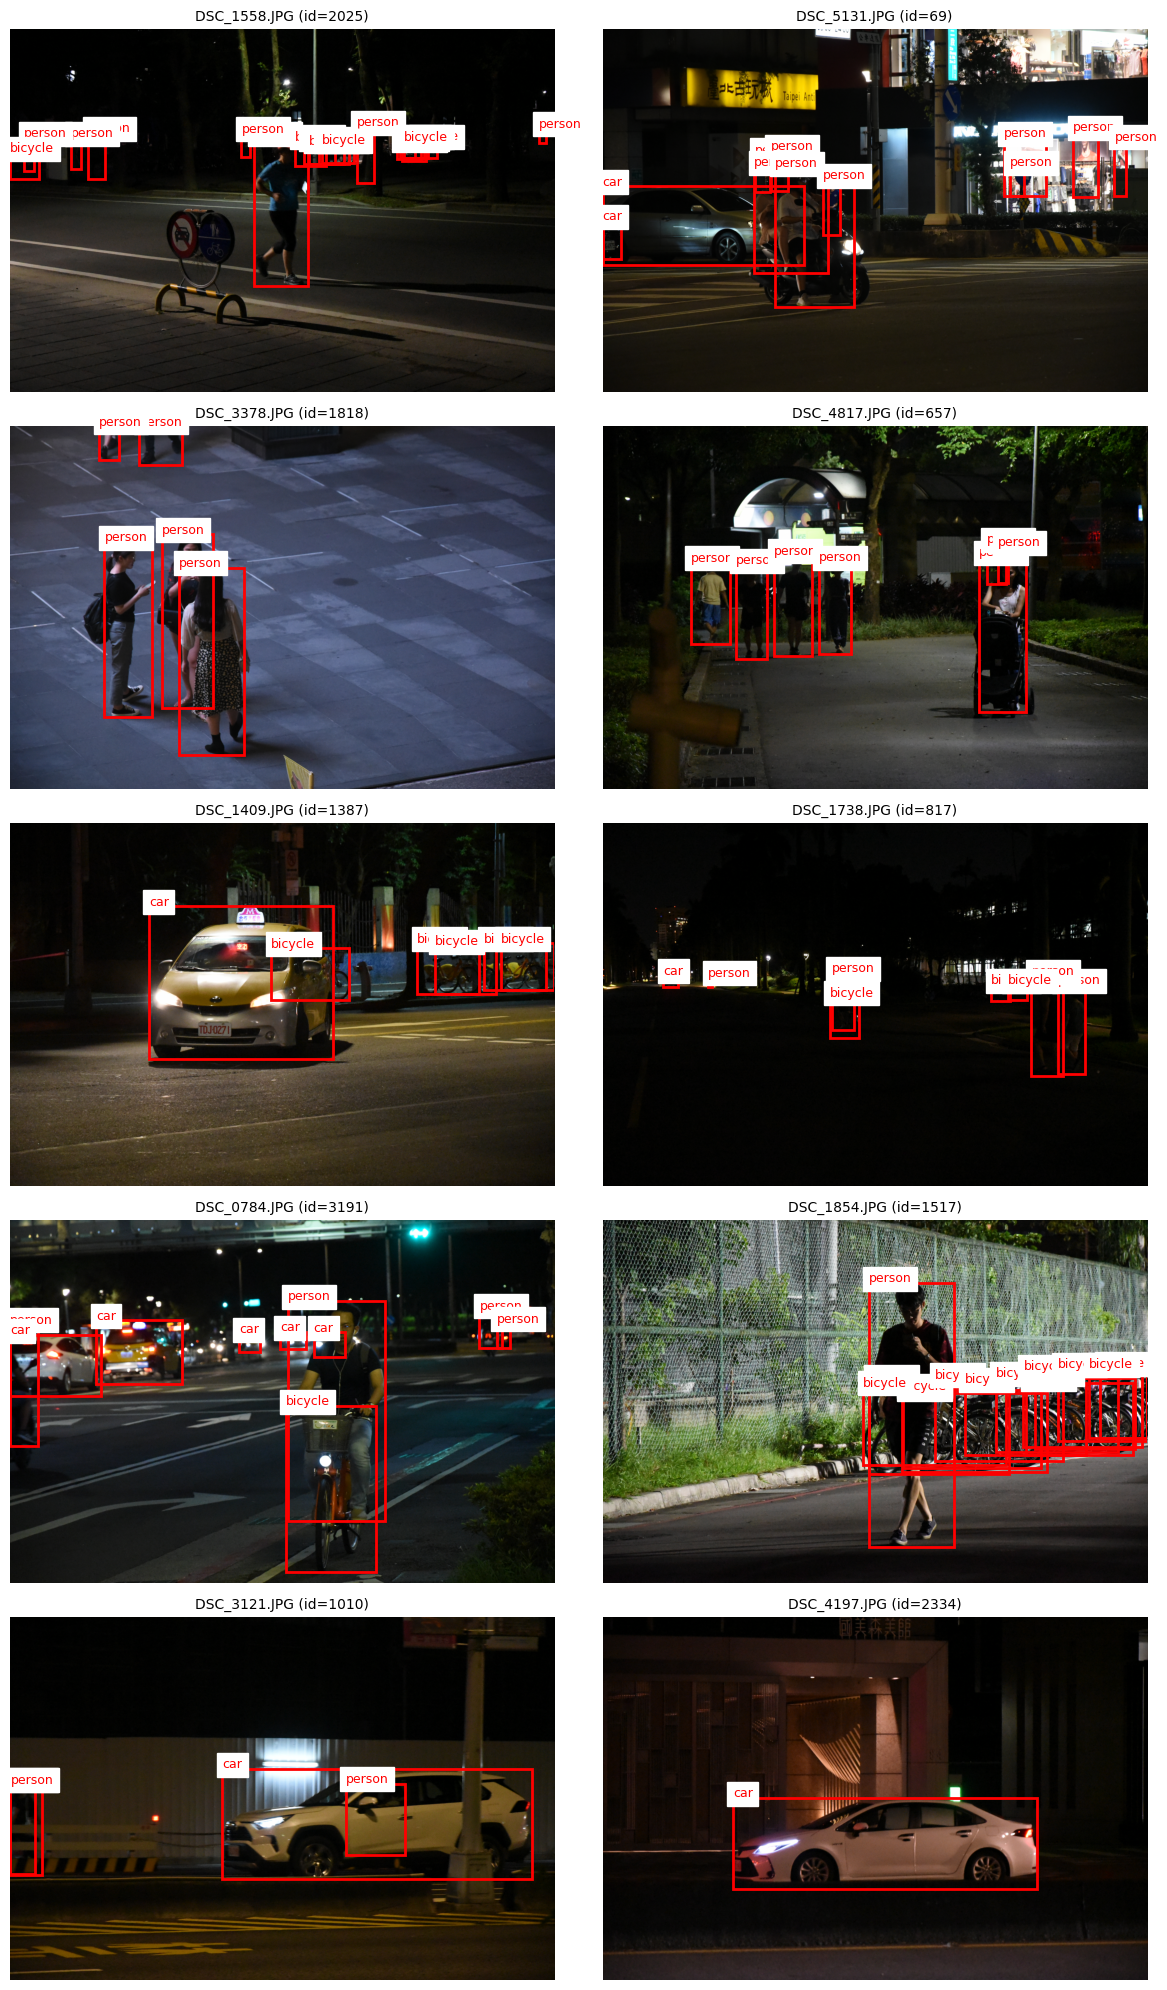

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image


def show_multiple_images(img_root, images, imgid_to_anns, catid_to_name, indices=None):
    """
    Show 10 images in a 5x2 grid with bounding boxes and labels.
    
    Args:
        img_root (str): path to images root.
        images (list): data["images"] list from COCO json.
        imgid_to_anns (dict): mapping image_id -> list of annotations.
        catid_to_name (dict): mapping category_id -> category name.
        indices (list or None): list of 10 indices into `images`. If None uses range(10).
    """
    if indices is None:
        indices = list(range(min(10, len(images))))
    else:
        # ensure at most 10 and valid indices
        indices = indices[:10]
        indices = [i for i in indices if 0 <= i < len(images)]
        if len(indices) == 0:
            raise ValueError("No valid image indices provided.")
    
    n = len(indices)
    rows, cols = 5, 2  # 5x2 grid
    fig, axes = plt.subplots(rows, cols, figsize=(12, 20))
    axes = axes.flatten()
    
    for ax in axes:
        ax.axis("off")
    
    for i, img_idx in enumerate(indices):
        ax = axes[i]
        img = images[img_idx]
        img_path = os.path.join(img_root, img["file_name"])
        
        # load and plot
        image = Image.open(img_path).convert("RGB")
        ax.imshow(image)
        ax.set_title(f'{img["file_name"]} (id={img["id"]})', fontsize=10)
        
        annots = imgid_to_anns.get(img["id"], [])
        for ann in annots:
            x, y, w, h = ann["bbox"]
            rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor="red", facecolor="none")
            ax.add_patch(rect)
            
            label = catid_to_name.get(ann["category_id"], str(ann["category_id"]))
            ax.text(x, y - 5, label, color="red", fontsize=9, backgroundcolor="white")
    
    # turn off any unused subplots (if less than 10 images)
    for j in range(n, rows * cols):
        axes[j].axis("off")
    
    plt.tight_layout()
    plt.show()


# Option A: first 10 images
show_multiple_images(nikon_data_root, data["images"], imgid_to_anns, catid_to_name)

# Option B: specific image indices (e.g., ids 100..109 in the `images` list)
# show_multiple_images(nikon_data_root, data["images"], imgid_to_anns, catid_to_name, indices=list(range(100, 110)))


In [24]:
import torch
import torch.nn as nn 
import torch.nn.functional as F
import numpy as np 
from typing import Union

def autopad(kernel_size:int, padding:int=None):
    """
    Calculate padding size automatically
    """
    if padding is None:
        return kernel_size // 2 if isinstance(kernel_size, int) else [k // 2 for k in kernel_size]
    return padding

def dist2bbox(distance:torch.Tensor, anchor_points:torch.Tensor, xywh:bool=True, dim:int=-1):
    """
    Transform distance in (ltrb) to bounding box (xywh) or (xyxy)
    """

    lt, rb = torch.chunk(distance, 2, dim=dim)
    xy_lt = anchor_points - lt
    xy_rb = anchor_points + rb

    if xywh:
        center = (xy_lt + xy_rb) / 2
        wh = xy_rb - xy_lt
        return torch.cat((center, wh), dim=dim)
    
    return torch.cat((xy_lt, xy_rb), dim=dim)

def bbox2dist(bbox:torch.Tensor, anchor_points:torch.Tensor, reg_max:int):
    """
    Transform bounding box (xyxy) to distance (ltrb)
    """
    xy_lt, xy_rb = torch.chunk(bbox, 2, dim=-1)
    lt = anchor_points - xy_lt
    rb = xy_rb - anchor_points
    return torch.cat((lt, rb), dim=-1).clamp(max=reg_max-0.01)

def init_weights(model:nn.Module):
    for m in model.modules():
        t = type(m)
        if t is nn.Conv2d:
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif t is nn.BatchNorm2d:
            m.eps = 1e-3
            m.momentum = 0.03
        elif t in (nn.ReLU, nn.SiLU):
            m.inplace = True

def make_anchors(feats:torch.Tensor, strides:torch.Tensor):
    anchor_points = []
    stride_tensor = []

    device = feats[0].device
    dtype = feats[0].dtype

    for i, stride in enumerate(strides):
        h, w = feats[i].shape[-2:]
        yv, xv = torch.meshgrid(torch.arange(h).to(device=device, dtype=dtype) + 0.5,
                                torch.arange(w).to(device=device, dtype=dtype) + 0.5)

        # (x,y) coordinates of center of each cell in grid
        anchor_points.append(torch.stack((xv, yv), dim=-1).view(-1, 2))
        stride_tensor.append(torch.full((h*w,1), stride).to(device=device, dtype=dtype))

    anchor_points = torch.cat(anchor_points, dim=0)
    stride_tensor = torch.cat(stride_tensor, dim=0)

    return anchor_points, stride_tensor

def xywh2xyxy_tensor(xywh:torch.Tensor):
    """
    Convert bounding box coordinates from (xywh) to (xyxy)
    """
    xy, wh = torch.chunk(xywh, 2, dim=-1)
    return torch.cat((xy - wh / 2, xy + wh / 2), dim=-1)

def xyxy2xywh(xyxy:torch.Tensor):
    """
    Convert bounding box coordinates from (xyxy) to (xywh)
    """
    xy_lt, xy_rb = torch.chunk(xyxy, 2, dim=-1)
    return torch.cat(((xy_lt + xy_rb) / 2, xy_rb - xy_lt), dim=-1)

def xywh2xyxy(xywh:np.ndarray):
    """
    Convert bounding box coordinates from (xywh) to (xyxy)
    """
    xy, wh = np.split(xywh, 2, axis=-1)
    return np.concatenate((xy - wh / 2, xy + wh / 2), axis=-1)

def xyxy2xywh(xyxy:np.ndarray):
    """
    Convert bounding box coordinates from (xyxy) to (xywh)
    """
    xy_lt, xy_rb = np.split(xyxy, 2, axis=-1)
    return np.concatenate(((xy_lt + xy_rb) / 2, xy_rb - xy_lt), axis=-1)

def pad_to(x:torch.Tensor, stride:int=None, shape:tuple[int,int]=None):
    """
    Pads an image with zeros to make it divisible by stride
    (Pads both top/bottom and left/right evenly) or pads to
    specified shape.

    Args:
        x (Tensor): image tensor of shape (..., h, w)
        stride (optional, int): stride of model
        shape (optional, Tuple[int,int]): shape to pad image to
    """
    h, w = x.shape[-2:]

    if stride is not None:
        h_new = h if h % stride == 0 else h + stride - h % stride
        w_new = w if w % stride == 0 else w + stride - w % stride
    elif shape is not None:
        h_new, w_new = shape

    t, b = int((h_new-h) / 2), int(h_new-h) - int((h_new-h) / 2)
    l, r = int((w_new-w) / 2), int(w_new-w) - int((w_new-w) / 2)
    pads = (l, r, t, b)

    x_padded = F.pad(x, pads, "constant", 0)

    return x_padded, pads

def unpad(x:torch.Tensor, pads:tuple):
    l, r, t, b = pads
    return x[..., t:-b, l:-r]

def pad_xyxy(xyxy:Union[np.ndarray, torch.Tensor], pads:tuple[int, int, int, int], im_size:tuple[int, int]=None, return_norm:bool=False):
    """
    Add padding to the bounding boxes based on image padding

    Args:
        xyxy: The bounding boxes in the format of `(x_min, y_min, x_max, y_max)`.
            if `im_size` is provided, assume this is normalized coordinates
        pad: The padding added to the image in the format
            of `(left, right, top, bottom)`.
        im_size: The size of the original image in the format of `(height, width)`.
        return_norm: Whether to return normalized coordinates
    """
    l, r, t, b = pads
    if return_norm and im_size is None:
        raise ValueError("im_size must be provided if return_norm is True")
    
    if im_size is not None:
        h, w = im_size
        hpad, wpad = h+b+t, w+l+r
    
    if isinstance(xyxy, np.ndarray):
        xyxy_unnorm = xyxy * np.array([w, h, w, h], dtype=xyxy.dtype) if im_size else xyxy
        padded = xyxy_unnorm + np.array([l, t, l, t], dtype=xyxy.dtype)
        if return_norm:
            padded /= np.array([wpad, hpad, wpad, hpad], dtype=xyxy.dtype)
        return padded
    
    xyxy_unnorm = xyxy * torch.tensor([w, h, w, h], dtype=xyxy.dtype, device=xyxy.device) if im_size else xyxy
    padded = xyxy_unnorm + torch.tensor([l, t, l, t], dtype=xyxy.dtype, device=xyxy.device)
    if return_norm:
        padded /= torch.tensor([wpad, hpad, wpad, hpad], dtype=xyxy.dtype, device=xyxy.device)
    return padded

def pad_xywh(xywh:Union[np.ndarray, torch.Tensor], pads:tuple[int, int, int, int], im_size:tuple[int, int]=None, return_norm:bool=False):
    """
    Add padding to the bounding boxes based on image padding

    Args:
        xywh: The bounding boxes in the format of `(x, y, w, h)`.
            if `im_size` is provided, assume this is normalized coordinates
        pad: The padding added to the image in the format
            of `(left, right, top, bottom)`.
        im_size: The size of the original image in the format of `(height, width)`.
        return_norm: Whether to return normalized coordinates
    """
    l, r, t, b = pads
    if return_norm and im_size is None:
        raise ValueError("im_size must be provided if return_norm is True")
    
    if im_size is not None:
        h, w = im_size
        hpad, wpad = h+b+t, w+l+r

    if isinstance(xywh, np.ndarray):
        xywh_unnorm = xywh * np.array([w, h, w, h], dtype=xywh.dtype) if im_size else xywh
        padded = xywh_unnorm + np.array([l, t, 0, 0], dtype=xywh.dtype)
        if return_norm:
            padded /= np.array([wpad, hpad, wpad, hpad], dtype=xywh.dtype)
        return padded
    
    xywh_unnorm = xywh * torch.tensor([w, h, w, h], dtype=xywh.dtype, device=xywh.device) if im_size else xywh
    padded = xywh_unnorm + torch.tensor([l, t, 0, 0], dtype=xywh.dtype, device=xywh.device)
    if return_norm:
        padded /= torch.tensor([wpad, hpad, wpad, hpad], dtype=xywh.dtype, device=xywh.device)
    return padded

def unpad_xyxy(xyxy:Union[np.ndarray, torch.Tensor], pads:tuple[int, int, int, int]):
    """
    Remove padding from the bounding boxes based on image padding

    Args:
        pad: The padding added to the image in the format
            of `(left, right, top, bottom)`.
    """
    l, r, t, b = pads
    if isinstance(xyxy, np.ndarray):
        return xyxy - np.array([l, t, l, t], dtype=xyxy.dtype)
    return xyxy - torch.tensor([l, t, l, t], dtype=xyxy.dtype, device=xyxy.device)

def box_iou_batch(gt_boxes: np.ndarray, pred_boxes: np.ndarray) -> np.ndarray:
    """
    Compute Intersection over Union (IoU) of two sets of bounding boxes -
        `gt_boxes` and `pred_boxes`. Both sets
        of boxes are expected to be in `(xyxy)` format.

    Args:
        gt_boxes (np.ndarray): 2D `np.ndarray` representing ground-truth boxes.
            `shape = (N, 4)` where `N` is number of true objects.
        pred_boxes (np.ndarray): 2D `np.ndarray` representing detection boxes.
            `shape = (M, 4)` where `M` is number of detected objects.

    Returns:
        np.ndarray: Pairwise IoU of boxes from `gt_boxes` and `pred_boxes`.
            `shape = (N, M)` where `N` is number of true objects and
            `M` is number of detected objects.
    """

    def box_area(box):
        return (box[2] - box[0]) * (box[3] - box[1])

    area_true = box_area(gt_boxes.T)
    area_detection = box_area(pred_boxes.T)

    top_left = np.maximum(gt_boxes[:, None, :2], pred_boxes[:, :2])
    bottom_right = np.minimum(gt_boxes[:, None, 2:], pred_boxes[:, 2:])

    area_inter = np.prod(np.clip(bottom_right - top_left, a_min=0, a_max=None), 2)
    return area_inter / (area_true[:, None] + area_detection - area_inter)

def non_max_suppression(predictions: np.ndarray, iou_threshold: float = 0.5) -> np.ndarray:
    """
    Perform Non-Maximum Suppression (NMS) on object detection predictions.

    Args:
        predictions (np.ndarray): An array of object detection predictions in
            the format of `(x_min, y_min, x_max, y_max, score)`
            or `(x_min, y_min, x_max, y_max, score, class)`.
        iou_threshold (float, optional): The intersection-over-union threshold
            to use for non-maximum suppression.

    Returns:
        np.ndarray: A boolean array indicating which predictions to keep after n
            on-maximum suppression.

    Raises:
        AssertionError: If `iou_threshold` is not within the
            closed range from `0` to `1`.
    """
    assert 0 <= iou_threshold <= 1, (
        "Value of `iou_threshold` must be in the closed range from 0 to 1, "
        f"{iou_threshold} given."
    )
    rows, columns = predictions.shape

    # add column #5 - category filled with zeros for agnostic nms
    if columns == 5:
        predictions = np.c_[predictions, np.zeros(rows)]

    # sort predictions column #4 - score
    sort_index = np.flip(predictions[:, 4].argsort())
    predictions = predictions[sort_index]

    boxes = predictions[:, :4]
    categories = predictions[:, 5]
    ious = box_iou_batch(boxes, boxes)
    ious = ious - np.eye(rows)

    keep = np.ones(rows, dtype=bool)

    for index, (iou, category) in enumerate(zip(ious, categories)):
        if not keep[index]:
            continue

        # drop detections with iou > iou_threshold and
        # same category as current detections
        condition = (iou > iou_threshold) & (categories == category)
        keep = keep & ~condition

    return keep[sort_index.argsort()]


In [27]:
import math
import torch
import cv2
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict

class Nikon750Dataset_Direct(Dataset):
    """
    Nikon750 dataset loader (COCO format)
    Compatible with YOLO-style detection heads
    """

    def __init__(
        self,
        img_root: str,
        ann_path: str,
        img_size: tuple[int, int] = (640, 640)
    ):
        super().__init__()
        self.img_root = img_root
        self.img_size = img_size

        # ---- Load COCO JSON ----
        with open(ann_path, "r") as f:
            coco = json.load(f)

        self.images = coco["images"]

        # category mapping: coco_id → continuous id
        self.catid_to_idx = {c["id"]: i for i, c in enumerate(coco["categories"])}

        # image_id → annotations
        self.imgid_to_anns = defaultdict(list)
        for ann in coco["annotations"]:
            if ann["iscrowd"] == 0:
                self.imgid_to_anns[ann["image_id"]].append(ann)

        print(f"[Nikon750] Loaded {len(self.images)} images from {ann_path}")

    def __len__(self):
        return len(self.images)

    # -------------------------
    # Image loader
    # -------------------------
    def _load_image(self, img_path: str):
        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        h0, w0 = image.shape[:2]

        # resize (same logic as your LoLiStreet dataset)
        if h0 > self.img_size[0] or w0 > self.img_size[1]:
            ratio = min(self.img_size[0] / h0, self.img_size[1] / w0)
            h, w = math.ceil(h0 * ratio), math.ceil(w0 * ratio)
            image = cv2.resize(image, (w, h), interpolation=cv2.INTER_LINEAR)
        else:
            h, w = h0, w0

        image = image.transpose(2, 0, 1)
        image = torch.from_numpy(image).float() / 255.0

        padded, pads = pad_to(image, shape=self.img_size)

        return padded, pads, (h0, w0)
    
    @staticmethod
    def collate_fn(batch):
        out = {}
        out["images"] = torch.stack([b["images"] for b in batch], 0)
        out["cls"] = torch.cat([b["cls"] for b in batch], 0)
        out["bboxes"] = torch.cat([b["bboxes"] for b in batch], 0)

        out["padding"] = [b["padding"] for b in batch]
        out["orig_shapes"] = [b["orig_shapes"] for b in batch]
        out["im_id"] = [b["im_id"] for b in batch]

        batch_idx = []
        for i, b in enumerate(batch):
            batch_idx.append(torch.full((b["cls"].shape[0],), i, dtype=torch.long))
        out["batch_idx"] = torch.cat(batch_idx, 0)

        return out

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_path = os.path.join(self.img_root, img_info["file_name"])

        image, pads, orig_shape = self._load_image(img_path)

        # ----- Load Annotations -----
        anns = self.imgid_to_anns.get(img_info["id"], [])

        if len(anns) == 0:
            cls = torch.empty((0,), dtype=torch.long)
            bboxes = torch.empty((0, 4), dtype=torch.float32)
        else:
            boxes = []
            labels = []
            for ann in anns:
                x, y, w, h = ann["bbox"]
                boxes.append([x + w / 2, y + h / 2, w, h])  # xywh (pixel)
                labels.append(self.catid_to_idx[ann["category_id"]])

            bboxes = torch.tensor(boxes, dtype=torch.float32)
            cls = torch.tensor(labels, dtype=torch.long)

            # normalize
            h0, w0 = orig_shape
            bboxes[:, [0, 2]] /= w0
            bboxes[:, [1, 3]] /= h0

            # apply padding (your util)
            bboxes = pad_xywh(
                bboxes,
                pads,
                orig_shape,
                return_norm=True
            )

        return {
            "images": image,
            "cls": cls,
            "bboxes": bboxes,
            "padding": pads,
            "orig_shapes": orig_shape,
            "im_id": img_info["file_name"]
        }




train_ds = Nikon750Dataset_Direct(
    img_root="Nikon750/Nikon750",
    ann_path="Nikon750/NOD_Nikon750_train.json",
    img_size=(640, 640)
)

val_ds = Nikon750Dataset_Direct(
    img_root="Nikon750/Nikon750",
    ann_path="Nikon750/NOD_Nikon750_val.json",
    img_size=(640, 640)
)

test_ds = Nikon750Dataset_Direct(
    img_root="Nikon750/Nikon750",
    ann_path="Nikon750/NOD_Nikon750_test.json",
    img_size=(640, 640)
)

train_loader = DataLoader(
    train_ds,
    batch_size=8,
    shuffle=True,
    collate_fn=Nikon750Dataset_Direct.collate_fn
)

val_loader = DataLoader(
    val_ds,
    batch_size=8,
    shuffle=True,
    collate_fn=Nikon750Dataset_Direct.collate_fn
)

test_loader = DataLoader(
    test_ds,
    batch_size=8,
    shuffle=False,
    collate_fn=Nikon750Dataset_Direct.collate_fn
)



[Nikon750] Loaded 3206 images from Nikon750/NOD_Nikon750_train.json
[Nikon750] Loaded 400 images from Nikon750/NOD_Nikon750_val.json
[Nikon750] Loaded 400 images from Nikon750/NOD_Nikon750_test.json


In [30]:
print("Train:", len(train_ds))
print("Val  :", len(val_ds))
print("Test :", len(test_ds))
print("Total:", len(train_ds) + len(val_ds) + len(test_ds))

sample = train_ds[0]

print(sample.keys())
print("Image:", sample["images"].shape)
print("Boxes:", sample["bboxes"].shape)
print("Labels:", sample["cls"].shape)
print("Padding:", sample["padding"])
print("Orig shape:", sample["orig_shapes"])
print("Image ID:", sample["im_id"])


print(sample['cls'])
print(sample['bboxes'])

Train: 3206
Val  : 400
Test : 400
Total: 4006
dict_keys(['images', 'cls', 'bboxes', 'padding', 'orig_shapes', 'im_id'])
Image: torch.Size([3, 640, 640])
Boxes: torch.Size([18, 4])
Labels: torch.Size([18])
Padding: (0, 0, 106, 107)
Orig shape: (2624, 3936)
Image ID: DSC_1558.JPG
tensor([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1])
tensor([[0.6529, 0.3569, 0.0305, 0.1421],
        [0.4980, 0.5021, 0.1006, 0.3768],
        [0.9784, 0.3088, 0.0127, 0.0374],
        [0.1593, 0.3595, 0.0315, 0.1170],
        [0.1211, 0.3539, 0.0191, 0.0804],
        [0.0348, 0.3560, 0.0178, 0.0846],
        [0.0262, 0.3863, 0.0523, 0.0670],
        [0.5527, 0.3548, 0.0572, 0.0631],
        [0.5694, 0.3546, 0.0564, 0.0543],
        [0.5814, 0.3572, 0.0633, 0.0483],
        [0.5958, 0.3560, 0.0549, 0.0479],
        [0.6030, 0.3551, 0.0592, 0.0462],
        [0.4333, 0.3326, 0.0160, 0.0596],
        [0.7335, 0.3493, 0.0427, 0.0388],
        [0.7386, 0.3463, 0.0447, 0.0398],
        [0.7647, 0.3430, 0.0